In [2]:
import pandas as pd
from datetime import datetime

## Read training and test datasets

In [3]:
# helper function for reading datatset
def read_data(file_path):
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d') # convert it to datatime

    return df

In [4]:
df_train = read_data('data/kospi_train.csv')
df_test = read_data('data/kospi_test.csv')

len(df_train), len(df_test)

(986, 244)

In [4]:
# the training dataset has daily KOSPI index from 2019 to 2022
df_train

,Date,Open,Low,High,Close,Volume
0,2019-01-02,2050.550049,2004.270020,2053.449951,2010.000000,326400
1,2019-01-03,2011.810059,1991.650024,2014.719971,1993.699951,428000
2,2019-01-04,1992.400024,1984.530029,2011.560059,2010.250000,409000
3,2019-01-07,2034.239990,2030.900024,2048.060059,2037.099976,440200
4,2019-01-08,2038.680054,2023.589966,2042.699951,2025.270020,397800
...,...,...,...,...,...,...
981,2022-12-23,2325.860107,2311.899902,2333.080078,2313.689941,367000
982,2022-12-26,2312.540039,2304.199951,2321.919922,2317.139893,427600
983,2022-12-27,2327.520020,2321.479980,2335.989990,2332.790039,448300
984,2022-12-28,2296.449951,2276.899902,2296.449951,2280.449951,405700


In [5]:
# the test dataset has daily KOSPI index in 2023
df_test

,Date,Open,Low,High,Close,Volume
0,2023-01-02,2249.949951,2222.370117,2259.879883,2225.669922,346100
1,2023-01-03,2230.979980,2180.669922,2230.979980,2218.679932,410000
2,2023-01-04,2205.979980,2198.820068,2260.060059,2255.979980,412700
3,2023-01-05,2268.199951,2252.969971,2281.389893,2264.649902,430800
4,2023-01-06,2253.399902,2253.270020,2300.620117,2289.969971,398300
...,...,...,...,...,...,...
239,2023-12-21,2598.370117,2587.159912,2610.810059,2600.020020,578300
240,2023-12-22,2617.719971,2599.510010,2621.370117,2599.510010,466000
241,2023-12-26,2609.439941,2594.649902,2612.139893,2602.590088,439500
242,2023-12-27,2599.350098,2590.080078,2613.500000,2613.500000,349700


## Part 1. Train regression models to predict the next day's `close` using `Open`, `Low`, `High`, `Close`, `Volume` of previous days as predictors using *only* df_train. Cross-validate to select the best model. Evaluate the accuracy of your model using `df_test`.


In [5]:
# Prepare training and testing X and y
X_train = df_train[['Open', 'Low', 'High', 'Close', 'Volume']].iloc[:-1].reset_index(drop=True)

# Shift the close price up by 1 day to predict tomorrow's close
y_train = df_train['Close'].shift(-1).dropna().reset_index(drop=True)

# No need to shift because test data is for direct prediction
X_test = df_test[['Open', 'Low', 'High', 'Close', 'Volume']]
y_test = df_test['Close']

In [6]:
# Define the linear regression model
from sklearn.linear_model import LinearRegression

# Create a linear regression model
linreg_model = LinearRegression()

In [7]:
# Cross-validate the linear regression model

# Import cross-validation tool and MSE scoring
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import get_scorer

# Get the scorer object from MSE
mse_scorer = get_scorer('neg_mean_squared_error')

# Perfrom 5 cross validation on the training data
cv_scores = cross_val_score(
    linreg_model,
    X_train,
    y_train,
    cv=5,
    scoring=mse_scorer
)

# Taking the negative MSE return to get true positive MSE values
cv_mse_scores = -cv_scores

# Print the cross validation MSE for each fold
print("Cross-validation MSE scores for each fold:", cv_mse_scores)

# Print the average CV MSE across all folds
print("Average CV MSE:", cv_mse_scores.mean())


Cross-validation MSE scores for each fold: [ 291.98254771 1180.14957781 1153.98936592  798.04701755  765.76259969]
Average CV MSE: 837.986221737903


In [8]:
# Train the linear regression model and predict 2023

# Train the model on the entire training set
linreg_model.fit(X_train, y_train)

# Predict the close prices for the 2023 test data
y_pred = linreg_model.predict(X_test)

In [9]:
# Evaluate the model on 2023 test data

# Import evaluation metrics 
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Calculate mean squared error
mse = mean_squared_error(y_test, y_pred)

# Calculate root mean squared error
rmse = np.sqrt(mse)

# Calculate mean asbolite error
mae = mean_absolute_error(y_test, y_pred)

# Print the results
print(f"Test MSE: {mse:.2f}")
print(f"Test RMSE: {rmse:.2f}")
print(f"Test MAE: {mae:.2f}")

Test MSE: 5.06
Test RMSE: 2.25
Test MAE: 1.89


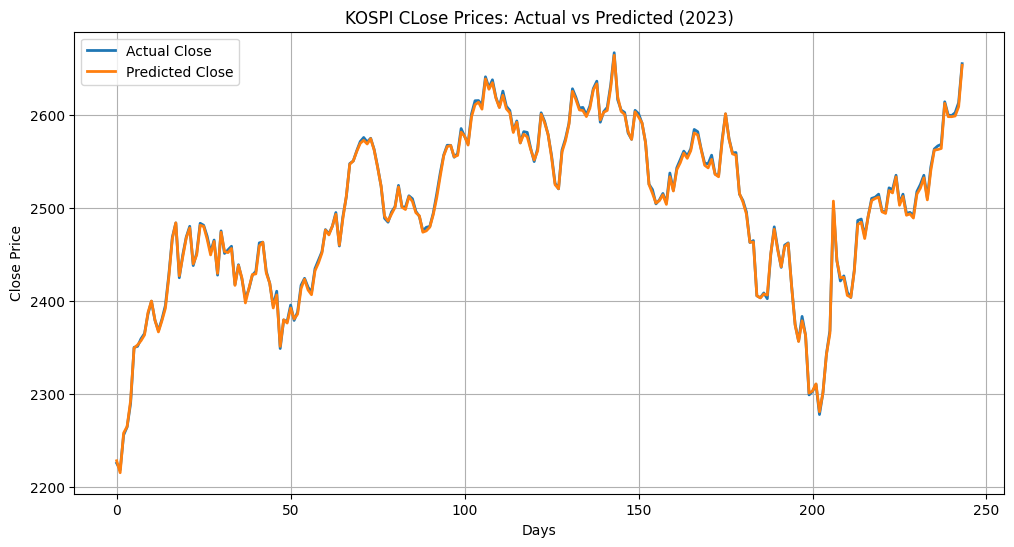

In [10]:
# Plotting real vs predicted close prices for 2023

import matplotlib.pyplot as plt

# Create a figure and axis
plt.figure(figsize=(12,6)) # width, height

# Plot real close prices
plt.plot(y_test.values, label='Actual Close', linewidth=2)

# Plot predicted close prices
plt.plot(y_pred, label='Predicted Close', linewidth=2)

plt.title('KOSPI CLose Prices: Actual vs Predicted (2023)')
plt.xlabel('Days')
plt.ylabel('Close Price')

# Add legend to show which line is which
plt.legend()

# Show grid for easier reading
plt.grid(True)

# Display the plot 
plt.show()


## Part 2. Extend the regression model by adding some extra features of your choice. You can use any statistics publicly available. 

In [12]:
# Function to calculate the 14-day RSI based on Close prices
# RSI is a standard technical indicator using rolling averages of gains and losses

import pandas as pd

def calculate_RSI(df, column='Close', period=14):
    #Calculate daily price changes
    delta = df[column].diff()

    # Seperate gains and losses
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    # Calculate the average gain and avergae loss using a rolling window
    avg_gain = gain.rolling(window=period, min_periods=period).mean()
    avg_loss = loss.rolling(window=period, min_periods=period).mean()

    # Calculate the Relative Strenght (RS)
    rs = avg_gain / avg_loss

    # Calculate the RSI
    rsi = 100 - (100 / (1 + rs))

    return rsi

df_train['RSI_14'] = calculate_RSI(df_train)
df_test['RSI_14'] = calculate_RSI(df_test)

In [13]:
# Show the last date in your test data and its RSI value
df_test[['Date', 'Close', 'RSI_14']].tail(1)


,Date,Close,RSI_14
243,2023-12-28,2655.280029,83.719638


In [ ]:
# Show the close prices of the last 15 days of data
df_test[['Date', 'Close']].tail(15)

,Date,Close
229,2023-12-07,2492.070068
230,2023-12-08,2517.850098
231,2023-12-11,2525.360107
232,2023-12-12,2535.270020
233,2023-12-13,2510.659912
234,2023-12-14,2544.179932
235,2023-12-15,2563.560059
236,2023-12-18,2566.860107
237,2023-12-19,2568.550049
238,2023-12-20,2614.300049
